In [4]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import RAW_DIR, LABELS

df = pd.read_csv(RAW_DIR / "train.csv")

print("Dataset shape:", df.shape)
print("\nNull values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nLabel stats:\n", df[LABELS].describe())

Dataset shape: (159571, 8)

Null values:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

Duplicate rows: 0

Label stats:
                toxic   severe_toxic        obscene         threat  \
count  159571.000000  159571.000000  159571.000000  159571.000000   
mean        0.095844       0.009996       0.052948       0.002996   
std         0.294379       0.099477       0.223931       0.054650   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       0.000000       0.000000   
50%         0.000000       0.000000       0.000000       0.000000   
75%         0.000000       0.000000       0.000000       0.000000   
max         1.000000       1.000000       1.000000       1.000000   

              insult  identity_hate  
count  159571.000000  159571.000000  
mean        0.049364       0.008805  
std         0.216627   

In [3]:
label_counts = df[LABELS].sum().sort_values(ascending=False)
percentages  = (label_counts / len(df) * 100).round(2)

print("\nLabel counts and % positive:")
for label in LABELS:
    print(f"  {label:<20} {label_counts[label]:>6}  ({percentages[label]:.2f}%)")


Label counts and % positive:
  toxic                 15294  (9.58%)
  severe_toxic           1595  (1.00%)
  obscene                8449  (5.29%)
  threat                  478  (0.30%)
  insult                 7877  (4.94%)
  identity_hate          1405  (0.88%)


In [5]:
# How many comments have multiple labels?
df['label_count'] = df[LABELS].sum(axis=1)
print(df['label_count'].value_counts())

# Clean (no label) vs toxic
clean = (df['label_count'] == 0).sum()
print(f"\nClean comments : {clean} ({clean/len(df)*100:.1f}%)")
print(f"Toxic comments : {len(df)-clean} ({(len(df)-clean)/len(df)*100:.1f}%)")

label_count
0    143346
1      6360
3      4209
2      3480
4      1760
5       385
6        31
Name: count, dtype: int64

Clean comments : 143346 (89.8%)
Toxic comments : 16225 (10.2%)


count    159571.000000
mean         67.273527
std          99.230702
min           1.000000
25%          17.000000
50%          36.000000
75%          75.000000
max        1411.000000
Name: text_len, dtype: float64

95th percentile length : 230 words
99th percentile length : 567 words


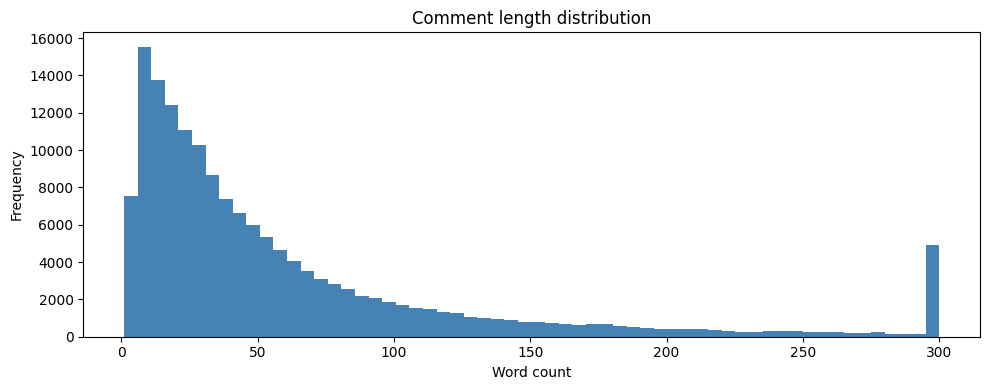

In [7]:
df['text_len'] = df['comment_text'].apply(lambda x: len(str(x).split()))

print(df['text_len'].describe())
print(f"\n95th percentile length : {df['text_len'].quantile(0.95):.0f} words")
print(f"99th percentile length : {df['text_len'].quantile(0.99):.0f} words")

# Plot
plt.figure(figsize=(10,4))
plt.hist(df['text_len'].clip(upper=300), bins=60, color='steelblue', edgecolor='none')
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.title("Comment length distribution")
plt.tight_layout()
plt.savefig("text_length.png", dpi=150)

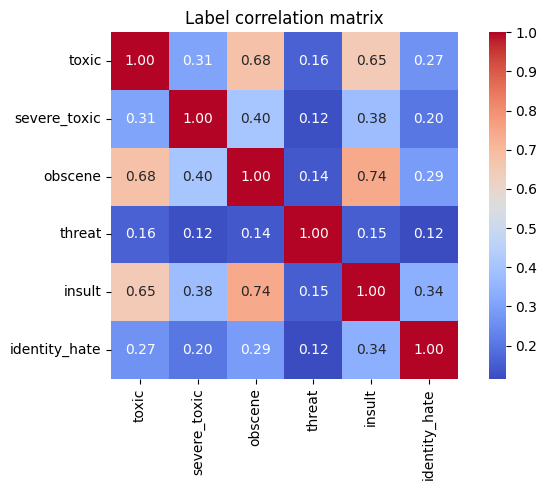

In [8]:
plt.figure(figsize=(7,5))
corr = df[LABELS].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Label correlation matrix")
plt.tight_layout()
plt.savefig("label_correlation.png", dpi=150)